# Loading modules

In [4]:
# WILD OAT https://github.com/asydesign/Wheat-Weed-Dataset
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import glob
import numpy as np
import random
import xml.etree.ElementTree as ET
from torchvision import transforms
import torch
from sklearn.metrics import f1_score, r2_score
from torch.utils.data import Dataset, WeightedRandomSampler
from typing import Tuple, Dict, List
import ResNet
import ViT
import PVTv2
import seaborn as sns
import pandas as pd
from utils.loss_utils import LabelSmoothingCrossEntropy
import EffNet

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.is_available()

C:\Users\EuanH\anaconda3\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\EuanH\anaconda3\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


True

# Loading Images from path

In [5]:
# Join images and labels together
dataset = []
val_dataset = []
names = ["cirsium arvense", "avena fatua", "setaria viridis"]
path = ["Dataset", "Dataset/validation"]
for p in path:
    for name in names:
        print(fr"./{p}/{name}/*.jpg")
        for filename in glob.glob(fr'./{p}/{name}/*.jpg'): 
            im = Image.open(filename)
            if p == "Dataset":
                dataset.append([im, name])
            else:
                val_dataset.append([im, name])

#for filename in glob.glob(r'./Dataset/avena fatua/*.jpg'): 
#    im = Image.open(filename)
#    dataset.append([im, "avena fatua"])

#for filename in glob.glob(r'./Dataset/setaria viridis/*.jpg'): 
#    im = Image.open(filename)
#    dataset.append([im, "setaria viridis"])

print(len(dataset))
print(len(val_dataset))

./Dataset/cirsium arvense/*.jpg
./Dataset/avena fatua/*.jpg
./Dataset/setaria viridis/*.jpg
./Dataset/validation/cirsium arvense/*.jpg
./Dataset/validation/avena fatua/*.jpg
./Dataset/validation/setaria viridis/*.jpg
2243
263


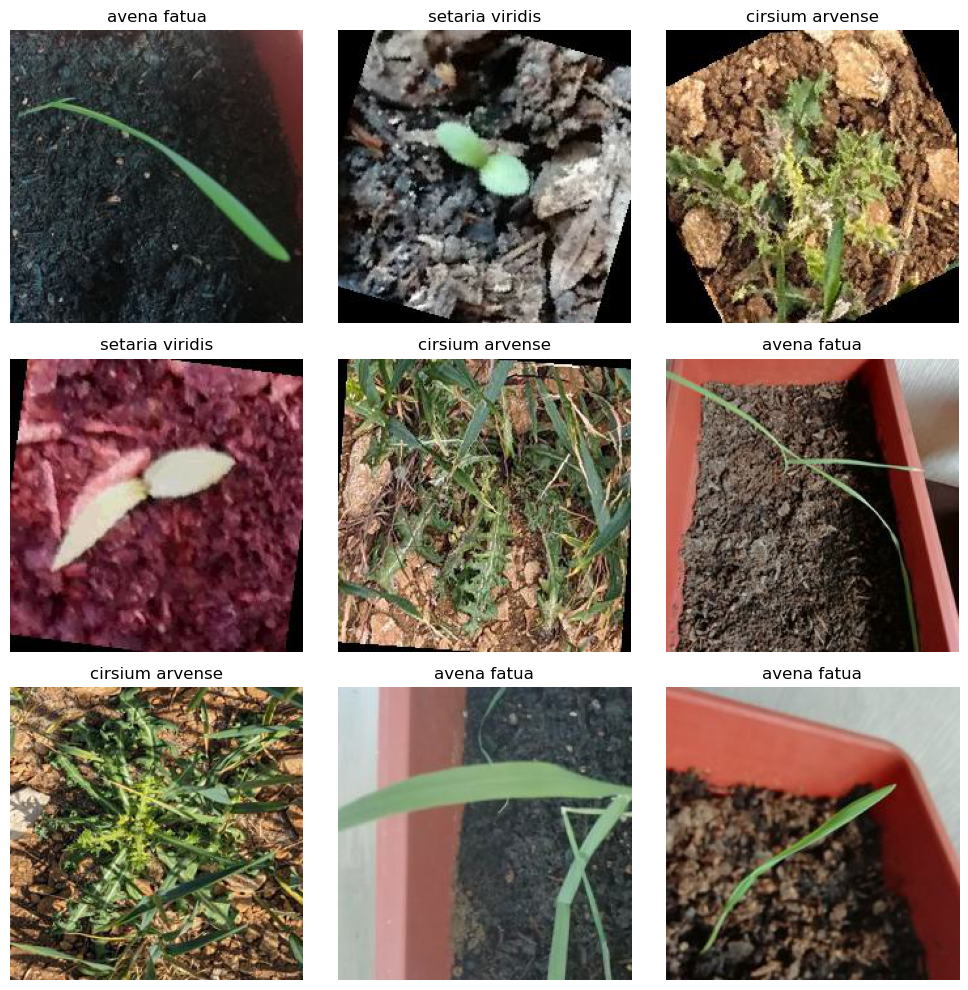

In [36]:
# CHECKING IF IMAGE IS NORMALIZED CORRECTLY
# Figure out how to extract the actual data from the images.
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i in range(0, 9):
    ran = random.randint(0, len(dataset))
    axes[i].imshow(dataset[ran][0])
    axes[i].axis('off')
    axes[i].set_title(dataset[ran][1])
    
plt.tight_layout()
plt.show()

# Defining custom dataset

In [6]:
# Custom Dataset initialization 
class WeedsDataset(Dataset):
    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, dataset: str, transform=None) -> None:
        self.images = dataset
        self.transform = transform
        self.class_idx = {"cirsium arvense" : 0, "avena fatua" : 1, "setaria viridis" : 2}

    def load_image(self, index: int) -> Image.Image:
        #rint(self.images[index])
        return self.images[index][0]
    
    def __len__(self) -> int:
        return len(self.images)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name  = self.images[index][1]
        class_idx = self.class_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

# Defining Testing and Training Steps

In [7]:
from tqdm.auto import tqdm
import torch.nn as nn

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "f1_score": [],
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        
        test_loss, test_acc, f1_score = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        
        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f} | "
            f"F1-Score: {f1_score:.4f} | "
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
        results["f1_score"].append(f1_score.item() if isinstance(f1_score, torch.Tensor) else f1_score)

        del train_loss, train_acc, test_loss, test_acc, f1_score


    # 6. Return the filled results at the end of the epochs
    return results

In [8]:
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()
    
    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0
    
    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)
        # 1. Forward pass
        
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
            
        train_loss += loss.item() 

        loss.backward()

        # Gradiant clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 5. Optimizer step
        optimizer.step()
        
        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch 
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [9]:
from tqdm.auto import tqdm
import torch.nn as nn

# 1. Take in various parameters required for training and test steps
def validation(model: torch.nn.Module, 
          val_dataloader: torch.utils.data.DataLoader, 
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {
        "val_loss": [],
        "val_acc": [],
        "f1_score": [],
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        val_loss, val_acc, f1_score = test_step(model=model,
            dataloader=val_dataloader,
            loss_fn=loss_fn)
        
        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"test_loss: {val_loss:.4f} | "
            f"test_acc: {val_acc:.4f} | "
            f"F1-Score: {f1_score:.4f} | "
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["val_loss"].append(val_loss.item() if isinstance(val_loss, torch.Tensor) else val_loss)
        results["val_acc"].append(val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc)
        results["f1_score"].append(f1_score.item() if isinstance(f1_score, torch.Tensor) else f1_score)

        del val_loss, val_acc, f1_score


    # 6. Return the filled results at the end of the epochs
    return results

In [10]:
def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() 

    y_true = []
    y_p = []
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    correct, incorrect = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            
            test_loss += loss.item()

            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            #print((test_pred_labels == y).sum().item(), len(test_pred_labels))
            #correct += (test_pred_labels == y).sum().item()
            #incorrect += len(y) - (test_pred_labels == y).sum()

            
            # Calculate and accumulate accuracy metrics across all batches
            y_p.extend(test_pred_labels.cpu().numpy())
            y_true.extend(y.cpu().numpy())

    # Calculating precision, recall, and F1 score using PyTorch
    # Convert lists to tensors for calculation
    f1 = f1_score(y_true, y_p, average="macro")
    #print(f"Actual values: {set(y_true)} :: Predictions {set(y_p)}")
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc, f1 # correct, incorrect

# Instanciating dataset with shuffles, augmentation, and normalisation

In [11]:
# Centering each image around 0 in a [-1, 1] range.
# https://medium.com/@piyushkashyap045/image-normalization-in-pytorch-from-tensor-conversion-to-scaling-3951b6337bc8 (Find more reliable source and cite)
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)
train_transforms = transforms.Compose([
    #transforms.TrivialAugmentWide(num_magnitude_bins=25), # how intense 
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean, std), # Is there any other way to normalize without calling compose twice?
    #transforms.RandomErasing(p=1), # Testing random erasure (not working for some reason)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


train_25 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std), 
    transforms.RandomErasing(p=0.25), # Testing random erasure (not working for some reason)
])


train_50 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std), 
    transforms.RandomErasing(p=0.5), # Testing random erasure (not working for some reason)
])

# Creating Test and Training sets 
length = len(dataset)
train_data_len = int(length*0.70)

# Creating train and test datasets
train_data, test_data = torch.utils.data.random_split(dataset, [train_data_len, length-train_data_len]) # 70 30 split

# Spltting test and validation data 
#lngth = len(test_data)
#train_data_len = int(lngth*0.5)
#test_data, validation_data = torch.utils.data.random_split(test_data, [train_data_len, lngth-train_data_len]) # 70 15 15

# Applying augmentations
train_data_0 = WeedsDataset(dataset=train_data, transform=train_transforms)
train_data_25 = WeedsDataset(dataset=train_data, transform=train_25)
train_data_50= WeedsDataset(dataset=train_data, transform=train_50)
test_data = WeedsDataset(dataset=test_data, transform=test_transforms)

# Applying augmentation to validation data
validation_data = WeedsDataset(dataset=val_dataset, transform=test_transforms)

from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_data_0, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

train_dataloader_25 = DataLoader(dataset=train_data_25, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

train_dataloader_50 = DataLoader(dataset=train_data_50, # use custom created train Dataset
                                     batch_size=32, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data, # use custom created test Dataset
                                    batch_size=32, 
                                    num_workers=0, 
                                    shuffle=False) # don't usually need to shuffle testing data

val_dataloader = DataLoader(dataset=validation_data, # use custom created test Dataset
                                    batch_size=32, 
                                    num_workers=0, 
                                    shuffle=True) 


In [36]:
## Training

# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 50

torch.autograd.set_detect_anomaly(False)
#EffNet = EfficientNet.EfficientNet("B1", in_channels=3, classes=3, show=False).to(device) # EfficientNet-B0 FIGURE OUT WHY TEST ACC ISN'T SHOWING
#RsNet = ResNet.ResNet50(channels=3, num_classes=3).to(device) # ResNet - FIGURE OUT WHY TEST ACC IS AT 100% ALL THE TIME


#vit_b16 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
#PvTv2 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 

# Setup loss function and optimizer
#loss = nn.CrossEntropyLoss().to(device)
loss = LabelSmoothingCrossEntropy().to(device)


# Start the timer
#from timeit import default_timer as timer 
# Creating Test and Training sets 
#length = len(dataset)
#train_data_len = int(length*0.80)
#train_data, test_data = train_set, val_set = torch.utils.data.random_split(dataset, [train_data_len, length-train_data_len])

#start_time = timer()

# Train model_0 
#img_batch, label_batch = next(iter(train_dataloader))
#PvTv2 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 
#rsnet = ResNet.ResNet50(3, channels=3).to(device) # ResNet - FIGURE OUT WHY TEST ACC IS AT 100% ALL THE TIME
eff_1 = EffNet.EfficientNet.from_name("efficientnet-b0", in_channels=3, num_classes=3, image_size=[224, 224]).to(device)
#p_1 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 
optimizer_5 = torch.optim.AdamW(params=eff_1.parameters(), lr=0.00001)
e_0 = train(model=eff_1, 
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer_5,
                        loss_fn=loss, 
                        epochs=NUM_EPOCHS)

eff_2 = EffNet.EfficientNet.from_name("efficientnet-b0", in_channels=3, num_classes=3, image_size=[224, 224]).to(device)
optimizer_7 = torch.optim.AdamW(params=eff_2.parameters(), lr=0.00001)
e_25 = train(model=eff_2, 
                        train_dataloader=train_dataloader_25,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer_7,
                        loss_fn=loss, 
                        epochs=NUM_EPOCHS)

eff_3 =  EffNet.EfficientNet.from_name("efficientnet-b0", in_channels=3, num_classes=3, image_size=[224, 224]).to(device) #ResNet.ResNet50(3, channels=3).to(device)
optimizer_6 = torch.optim.AdamW(params=eff_3.parameters(), lr=0.00001)
e_50 = train(model=eff_3, 
                        train_dataloader=train_dataloader_50,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer_6,
                        loss_fn=loss, 
                        epochs=NUM_EPOCHS)

#p_2 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 
#optimizer_7 = torch.optim.AdamW(params=p_2.parameters(), lr=0.00001)
#pv_25 = train(model=p_2, 
#                        train_dataloader=train_dataloader_25,
#                        test_dataloader=test_dataloader,
#                        val_dataloader=val_dataloader,
#                        optimizer=optimizer_7,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)

#p_3 = PVTv2.pvt_v2_b0(num_classes=3, pretrained=None).to(device) 
#optimizer_8 = torch.optim.AdamW(params=p_3.parameters(), lr=0.00001)
#pv_50 = train(model=p_3, 
#                        train_dataloader=train_dataloader_50,
#                        test_dataloader=test_dataloader,
#                        val_dataloader=val_dataloader,
#                        optimizer=optimizer_8,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)


#torch.save(p_1.state_dict(), "PvTv2-0-Weights")
#torch.save(p_2.state_dict(), "PvTv2-25-Weights")
#torch.save(p_3.state_dict(), "PvTv2-50-Weights")

#torch.cuda.empty_cache()
#train_dataloader_1 = train_dataloader
#img_batch, label_batch = next(iter(train_dataloader_1))
#v_1 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
#optimizer_1 = torch.optim.AdamW(params=v_1.parameters(), lr=0.00001)
#v_0 = train(model=v_1, 
#                        train_dataloader=train_dataloader,
#                        test_dataloader=test_dataloader,
#                        optimizer=optimizer_1,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)

#train_dataloader_2 = train_dataloader
#img_batch, label_batch = next(iter(train_dataloader_2))
#v_2 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
#optimizer_2 = torch.optim.AdamW(params=v_2.parameters(), lr=0.00001)
#v_25 = train(model=v_2, 
                        #train_dataloader=train_dataloader_25,
                       # test_dataloader=test_dataloader,
                        #val_dataloader=val_dataloader,
                       # optimizer=optimizer_2,
                       # loss_fn=loss, 
                       # epochs=NUM_EPOCHS)

#train_dataloader_3 = train_dataloader
#img_batch, label_batch = next(iter(train_dataloader_3))
#v_3 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
#optimizer_3 = torch.optim.AdamW(params=v_3.parameters(), lr=0.00001)
#v_50 = train(model=v_3, 
                      #  train_dataloader=train_dataloader_50,
                       # test_dataloader=test_dataloader,
                      #  val_dataloader=val_dataloader,
                      #  optimizer=optimizer_3,
                       # loss_fn=loss, 
                       # epochs=NUM_EPOCHS)


#torch.save(v_1.state_dict(), "ViT-0-Weights")
#torch.save(v_2.state_dict(), "ViT-25-Weights")
#torch.save(v_3.state_dict(), "ViT-50-Weights")

#img_batch, label_batch = next(iter(train_dataloader_25))
#vit_b16_25 = ViT.ViTClassifier(img_batch, num_classes=3).to(device) 
#optimizer_0 = torch.optim.AdamW(params=vit_b16_25.parameters(), lr=0.00001) #EN.EfficientNet("B0", in_channels=3, classes=3, show=False).to(device) #
#v_25 = train(model=vit_b16_25, 
#                        train_dataloader=train_dataloader_25,
#                        test_dataloader=test_dataloader,
#                        optimizer=optimizer_0,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)

#img_batch, label_batch = next(iter(train_dataloader_50))
#img_batch, label_batch = next(iter(train_dataloader_50))
#vit_b16_50 = ViT.ViTClassifier(img_batch, num_classes=3).to(device)   #EN.EfficientNet("B0", in_channels=3, classes=3, show=False).to(device) #
#optimizer_1 = torch.optim.AdamW(params=vit_b16_50.parameters(), lr=0.00001)
#v_50 = train(model=vit_b16_50, 
#                        train_dataloader=train_dataloader_50,
#                        test_dataloader=test_dataloader,
#                        optimizer=optimizer_1,
#                        loss_fn=loss, 
#                        epochs=NUM_EPOCHS)

#end_time = timer()
#print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0441 | train_acc: 0.4600 | test_loss: 1.0988 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 2 | train_loss: 1.0178 | train_acc: 0.4869 | test_loss: 1.1001 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 3 | train_loss: 0.9921 | train_acc: 0.5156 | test_loss: 1.1025 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 4 | train_loss: 0.9596 | train_acc: 0.5519 | test_loss: 1.1093 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 5 | train_loss: 0.9306 | train_acc: 0.5875 | test_loss: 1.1195 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 6 | train_loss: 0.8378 | train_acc: 0.6663 | test_loss: 1.1405 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 7 | train_loss: 0.7802 | train_acc: 0.7106 | test_loss: 1.1765 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 8 | train_loss: 0.7252 | train_acc: 0.7369 | test_loss: 1.2285 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 9 | train_loss: 0.7181 | train_acc: 0.7431 | test_loss: 1.2852 | test_acc: 0.3054 | F1-Score: 0.1614 | 
E

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0687 | train_acc: 0.4119 | test_loss: 1.0993 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 2 | train_loss: 1.0333 | train_acc: 0.4850 | test_loss: 1.1014 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 3 | train_loss: 0.9988 | train_acc: 0.5544 | test_loss: 1.1038 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 4 | train_loss: 0.9499 | train_acc: 0.5944 | test_loss: 1.1078 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 5 | train_loss: 0.8983 | train_acc: 0.6356 | test_loss: 1.1153 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 6 | train_loss: 0.8362 | train_acc: 0.6750 | test_loss: 1.1287 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 7 | train_loss: 0.8156 | train_acc: 0.6794 | test_loss: 1.1468 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 8 | train_loss: 0.7615 | train_acc: 0.7200 | test_loss: 1.1675 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 9 | train_loss: 0.7151 | train_acc: 0.7475 | test_loss: 1.2070 | test_acc: 0.3054 | F1-Score: 0.1614 | 
E

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0839 | train_acc: 0.4037 | test_loss: 1.0991 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 2 | train_loss: 1.0628 | train_acc: 0.4450 | test_loss: 1.0998 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 3 | train_loss: 1.0247 | train_acc: 0.4831 | test_loss: 1.1005 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 4 | train_loss: 0.9720 | train_acc: 0.5644 | test_loss: 1.1013 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 5 | train_loss: 0.9279 | train_acc: 0.5869 | test_loss: 1.1032 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 6 | train_loss: 0.8586 | train_acc: 0.6475 | test_loss: 1.1041 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 7 | train_loss: 0.8115 | train_acc: 0.6787 | test_loss: 1.1073 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 8 | train_loss: 0.7742 | train_acc: 0.7019 | test_loss: 1.1137 | test_acc: 0.3054 | F1-Score: 0.1614 | 
Epoch: 9 | train_loss: 0.7437 | train_acc: 0.7388 | test_loss: 1.0802 | test_acc: 0.3097 | F1-Score: 0.1709 | 
E

# Saving Model Weights

In [37]:
# Print model's state_dict
torch.save(eff_1.state_dict(), "Effnet-0-50-Weights")
torch.save(eff_2.state_dict(), "Effnet-25-50-Weights")
torch.save(eff_3.state_dict(), "Effnet-50-50-Weights")

In [12]:
# Loading results for validation
torch.manual_seed(42) 
torch.cuda.manual_seed(42)
NUM_EPOCHS = 50
torch.autograd.set_detect_anomaly(False)

# Setup loss function and optimizer
#loss = nn.CrossEntropyLoss().to(device)
loss = LabelSmoothingCrossEntropy().to(device)
#eff = EffNet.EfficientNet.from_pretrained("efficientnet-b0", "EfficientNet-0-Weights", in_channels=3, num_classes=3, image_size=[224, 224]).to(device)
#res = ResNet.ResNet50(num_classes=3).to(device)
#res.load_state_dict(torch.load("ResNet-50-50-Weights", weights_only=True))
PvTv2 = PVTv2.pvt_v2_b0(classes=3, pretrained=torch.load("PvTv2-0-Weights", weights_only=True)).to(device)
#v_0 = ViT.ViTClassifier(img_n_1, num_classes=3, pretrained=torch.load("ViT-0-Weights", weights_only=True)).to(device) 

model = validation(model=PvTv2, 
          val_dataloader=val_dataloader, 
          loss_fn=loss,
          epochs=NUM_EPOCHS)

title = ['Validation Loss', 'Validation Accuracy', 'F1 Score']
labels = ['val_loss', 'val_acc' 'f1_score']

# Figure out how to extract the actual data from the images.
df = pd.DataFrame(model)
print(df)

sns.set_theme()
f, axes = plt.subplots(2, 2, figsize=(9, 10))
axes = axes.flatten()
ax = sns.lineplot(data=df[["val_loss"]], ax=axes[0])
ax.set(title="Validation Loss", ylabel="Loss", xlabel="Epoch")
lgd = sns.move_legend(ax, "upper left", bbox_to_anchor=(0.5,1))

ax2 = sns.lineplot(data=df[["val_acc"]], ax=axes[1])
ax2.set(title="Validation Accuracy", ylabel="Percentage (%)", xlabel="Epoch")
lgd2 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))

ax3 = sns.lineplot(data=df[["f1_score"]], ax=axes[2])
ax3.set(title="F1 Score", ylabel="Score", xlabel="Epoch")
lgd3 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))
fig = f.get_figure()
#fig.savefig("effnet 32 Batch 50 Epoch 50% LabelSmoothingCrossEntropy.png", dpi=300, bbox_inches='tight')

df.to_csv("PvTv2 50 0 testing%.csv", index=True)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | test_loss: 6.8433 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 2 | test_loss: 6.8473 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 3 | test_loss: 6.8409 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 4 | test_loss: 6.8488 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 5 | test_loss: 6.8410 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 6 | test_loss: 6.8543 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 7 | test_loss: 6.8490 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 8 | test_loss: 6.8452 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 9 | test_loss: 6.8495 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 10 | test_loss: 6.8459 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 11 | test_loss: 6.8476 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 12 | test_loss: 6.8545 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 13 | test_loss: 6.8434 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 14 | test_loss: 6.8421 | test_acc: 0.0000 | F1-Score: 0.0000 | 
Epoch: 15 | tes

OutOfMemoryError: CUDA out of memory. Tried to allocate 98.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 12.47 GiB is allocated by PyTorch, and 232.04 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# Plotting Results

    train_loss  train_acc  test_loss  test_acc  f1_score
0     1.083899   0.403750   1.099134  0.305398  0.161411
1     1.062785   0.445000   1.099846  0.305398  0.161411
2     1.024686   0.483125   1.100471  0.305398  0.161411
3     0.971966   0.564375   1.101347  0.305398  0.161411
4     0.927875   0.586875   1.103241  0.305398  0.161411
5     0.858595   0.647500   1.104121  0.305398  0.161411
6     0.811528   0.678750   1.107294  0.305398  0.161411
7     0.774248   0.701875   1.113672  0.305398  0.161411
8     0.743724   0.738750   1.080219  0.309659  0.170914
9     0.718912   0.756875   1.017108  0.414773  0.360186
10    0.679741   0.789375   0.831606  0.623580  0.627922
11    0.634895   0.804375   0.670012  0.779830  0.768694
12    0.619548   0.823750   0.596495  0.839489  0.833956
13    0.596427   0.842500   0.548107  0.856534  0.850110
14    0.594694   0.839375   0.530380  0.872159  0.867875
15    0.567710   0.853750   0.523102  0.882102  0.878284
16    0.542980   0.862500   0.5

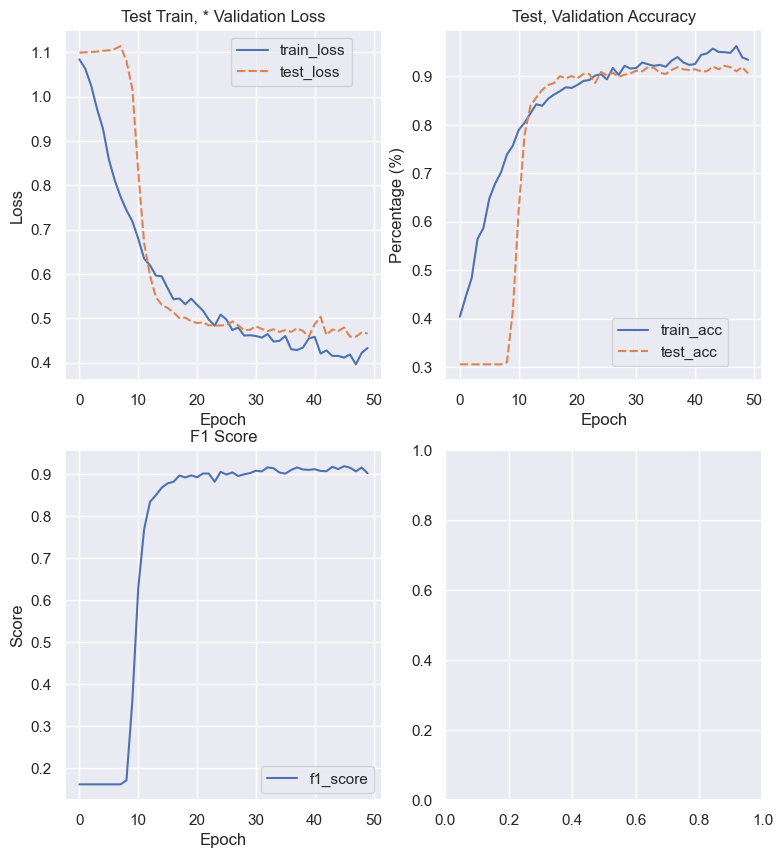

In [41]:
x = [i for i in range(1, NUM_EPOCHS+1)]

title = ['Train Accuracy & Loss', 'Test Accuracy & Loss', 'F1 Score']
labels = ['train_loss', 'train_acc', 'test_loss', 'test_acc' 'f1_score']

# CHECKING IF IMAGE IS NORMALIZED CORRECTLY
# Figure out how to extract the actual data from the images.
model_0_results = e_50
df = pd.DataFrame(model_0_results)
print(df)
sns.set_theme()
f, axes = plt.subplots(2, 2, figsize=(9, 10))
axes = axes.flatten()
ax = sns.lineplot(data=df[["train_loss", "test_loss"]], ax=axes[0])
ax.set(title="Test Train, * Validation Loss", ylabel="Loss", xlabel="Epoch")
lgd = sns.move_legend(ax, "upper left", bbox_to_anchor=(0.5,1))

ax2 = sns.lineplot(data=df[["train_acc", "test_acc"]], ax=axes[1])
ax2.set(title="Test, Validation Accuracy", ylabel="Percentage (%)", xlabel="Epoch")
lgd2 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))

ax3 = sns.lineplot(data=df[["f1_score"]], ax=axes[2])
ax3.set(title="F1 Score", ylabel="Score", xlabel="Epoch")
lgd3 = sns.move_legend(ax2, "upper left", bbox_to_anchor=(0.5,0.2))
fig = f.get_figure()
fig.savefig("effnet 32 Batch 50 Epoch 50% LabelSmoothingCrossEntropy.png", dpi=300, bbox_inches='tight')

df.to_csv("eff 50 50%.csv", index=True)